### Monte Carlo method root finding

Find the root $x_0 \in [0, 1]$ of the function $e^x - 3 \, x$ using a Monte Carlo approach

In [1]:
import numpy as np
from scipy.optimize import bisect
import matplotlib.pyplot as plt

In [2]:
f = lambda x: np.exp(x) - 3.0 * x # e^x - 3x = 0

In [3]:
def monte_carlo_root(f, a, b, N): # Quick Monte Carlo method

    x = np.random.uniform( # N points uniformly distributed in [a, b]
        low = a,
        high = b,
        size = N
    )

    fx = f(x)
    ind = np.argmin(np.abs(fx)) # Index of the root
    root = x[ind]
    residual = fx[ind]

    return root, residual # Returns the root and the residual f(root)

In [4]:
a, b = 0.0, 1.0 # [0, 1]
N = 10_000 # Number of points

In [5]:
monte_carlo_root(f, a, b, N), monte_carlo_root(f, a, b, N), monte_carlo_root(f, a, b, N) # 3 independent runs

((np.float64(0.6190549202520099), np.float64(7.2757582325611025e-06)),
 (np.float64(0.6190127093907868), np.float64(5.551716529228479e-05)),
 (np.float64(0.6190020332650905), np.float64(6.77190830289387e-05)))

To estimate an error, let's run 1000 times the algorithm. Take mean and twice standard deviation

In [6]:
M = 1_000 # Numbers of runs
roots = np.array([monte_carlo_root(f, a, b, N) for _ in range(M)]) # Roots array
roots

array([[ 6.19128460e-01, -7.67623134e-05],
       [ 6.19102733e-01, -4.73642917e-05],
       [ 6.19073224e-01, -1.36418189e-05],
       ...,
       [ 6.19025018e-01,  4.14497084e-05],
       [ 6.18970859e-01,  1.03349617e-04],
       [ 6.18991278e-01,  8.00112467e-05]], shape=(1000, 2))

In [ ]:
root_MC, err = np.mean(roots[:, 0]), 2.0 * np.std(roots[:, 0]) # Results
root_MC, err

(np.float64(0.6190619656659053), np.float64(0.00014352004615377807))

We've found:

$$
    x_0 = 0.6191 \pm 0.0001
$$

In [8]:
bisect( # by SciPy
    f = f,
    a = a,
    b = b,
    xtol = 1e-06
)

0.6190614700317383

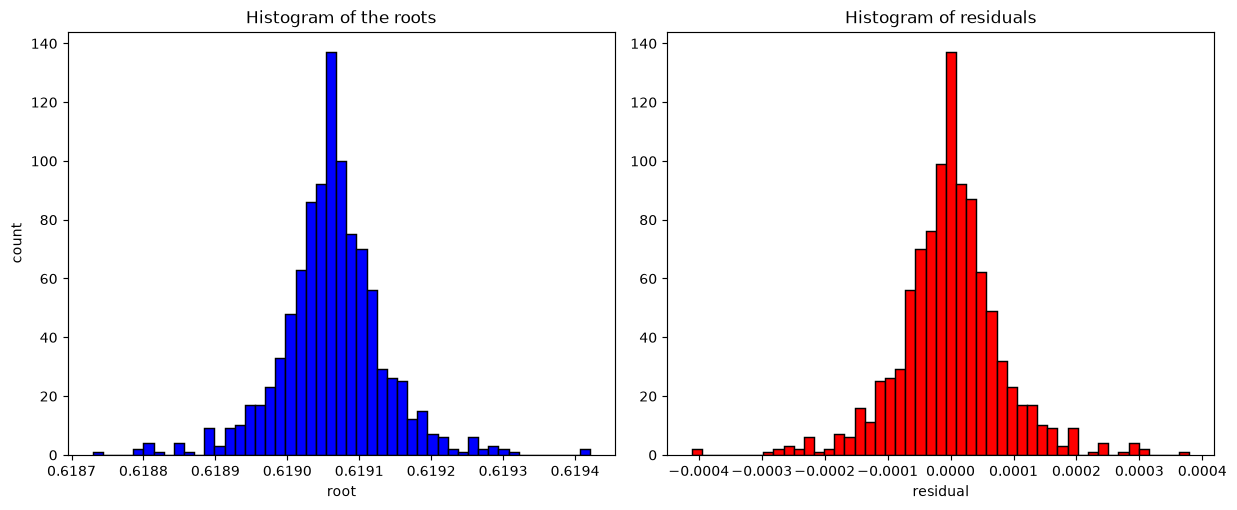

In [9]:
# Fast plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

# Histogram of roots (left)
ax1.hist(roots[:, 0], bins = 'auto', density = False, color = 'blue', edgecolor = 'black')
ax1.set_title("Histogram of the roots")
ax1.set_xlabel("root")
ax1.set_ylabel("count")

# Histogram of residuals (right)
ax2.hist(roots[:, 1], bins='auto', density = False, color = 'red', edgecolor = 'black')
ax2.set_title("Histogram of residuals")
ax2.set_xlabel("residual")

plt.tight_layout()
plt.show()